# Polynomial Regression

## Imports

In [437]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.set_up import set_up
from src.datasets.dataset import Dataset
from src.models.polynomial_regression import PolynomialRegression
import src.utility.util as utl
from src.utility.trainer import run_training, test_model

In [438]:
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count()
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count(), torch.cuda.current_device()if torch.cuda.is_available() else 'CUDA not available'

use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


## Datasets

We have four datasets we want to train our models on:
* **A1**: A1 contains samples with and without review scores / sentiment features. Each sample has an indicator whether it had reviews or not. Missing values are filled with 0. (A1 is the dataset we obtain from 02_preprocessing.ipynb).
* **A2**: A2 contains only samples with all review scores and sentiment features.
* **B1**: B1 contains only samples without review scores. The review scores and sentiment columns are dropped after preprocessing.  
* **B2**: B2 contains samples with and without review scores. The review scores and sentiment columns are dropped after preprocessing.

All the other features are processed the same way in each set and the test set is the same for each set. See src/data/loading.py for more details.

The point is that not every listing has gotten reviews, especially new ones. Therefore we want to try models that do not rely on reviews.

We create all our datasets, so we can load and use them for training (see **src/set_up.py**).

In [439]:
load = True
if load:
    set_up()

c:\Users\Victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['boatslip', 'freeresortaccess', 'paidresortaccess', 'private_gym'] will be ignored
  warnings.warn(


## A1

### Load

In [440]:
# Load training and test sets
X_train_A1 = pd.read_parquet('../data/processed/A1/X_train.parquet', engine='pyarrow')
y_train_A1 = pd.read_parquet('../data/processed/A1/y_train.parquet', engine='pyarrow')
X_test_A1 = pd.read_parquet('../data/processed/A1/X_test.parquet', engine='pyarrow')
y_test_A1 = pd.read_parquet('../data/processed/A1/y_test.parquet', engine='pyarrow')

In [441]:
print(X_train_A1.info(), '\n')
print(X_test_A1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12170 entries, 5483 to 10222
Data columns (total 78 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   host_since                                        12170 non-null  float64
 1   host_response_time                                12170 non-null  float64
 2   host_response_rate                                12170 non-null  float64
 3   host_acceptance_rate                              12170 non-null  float64
 4   host_is_superhost                                 12170 non-null  float64
 5   host_listings_count                               12170 non-null  float64
 6   host_has_profile_pic                              12170 non-null  float64
 7   host_identity_verified                            12170 non-null  float64
 8   neighbourhood_cleansed                            12170 non-null  float64
 9   latitude           

Calculate mean and standard deviation of the train set.

In [442]:
# Calculate mean and std
mean_train_A1 = X_train_A1.mean().to_numpy()
std_train_A1 = X_train_A1.std().to_numpy()

Initialise Datasets.

In [443]:
# Init Dataset
dataset_train_A1 = Dataset(X_train_A1, y_train_A1, mean_train_A1, std_train_A1)
dataset_test_A1 = Dataset(X_test_A1, y_test_A1, mean_train_A1, std_train_A1)

Create train and validation sets.

In [444]:
# Split for validation set
size_total = len(dataset_train_A1)
size_val = int(0.1 * size_total)
size_train = size_total - size_val

dataset_train_A1, dataset_val_A1 = torch.utils.data.random_split(
    dataset_train_A1,
    [size_train, size_val]
)

Initialise DataLoaders.

In [445]:
dataloader_train_A1 = DataLoader(dataset_train_A1, batch_size=64, shuffle=True)
dataloader_val_A1 = DataLoader(dataset_val_A1, batch_size=64, shuffle=False)
dataloader_test_A1 = DataLoader(dataset_test_A1, batch_size=64, shuffle=False)

Specify model, optimizer and loss function.

In [446]:
# Hyperparameters
params_A1 = {
    'degree': 2,
    'num_epochs': 15,
    'weight_decay': 0.01,
    'input_dim': X_train_A1.shape[1],
    'output_dim': 1,
    'lr': 0.001
}

In [447]:
model_A1 = PolynomialRegression(input_dim=params_A1['input_dim'], output_dim=params_A1['output_dim'], degree=params_A1['degree']).to(device)
optimizer_A1 = torch.optim.Adam(model_A1.parameters(), lr=params_A1['lr'], weight_decay=params_A1['weight_decay'])
loss_fn = torch.nn.MSELoss()

### Run training

In [448]:
losses_train_A1, losses_val_A1 = run_training(model_A1, optimizer_A1, loss_fn, dataloader_train_A1, dataloader_val_A1, epochs=params_A1['num_epochs'], device=device)

100%|██████████| 15/15 [00:17<00:00,  1.17s/it]


In [449]:
print(losses_train_A1, '\n')
print(losses_val_A1)

[9.18572509 1.14686859 0.5720345  0.42188218 0.35856387 0.30380508
 0.27024172 0.25288634 0.2308697  0.21955393 0.22113394 0.25542287
 0.29609121 0.4700518  0.39576566] 

[1.17786954 0.60502753 0.44475426 0.3734361  0.32639652 0.28863244
 0.2644712  0.24576503 0.23627562 0.22544323 0.2067897  0.20210183
 0.22887217 0.21488994 0.23181954]


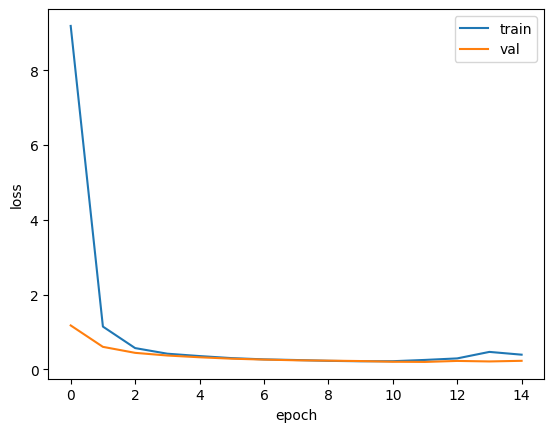

In [450]:
utl.plot_losses(losses_train_A1, losses_val_A1)

### Testing

In [451]:
predictions_A1_log, prices_A1_log, test_loss_A1_log = test_model(model_A1, loss_fn, dataloader_test_A1, device)

test_loss_A1 = np.expm1(test_loss_A1_log)
predictions_A1 = np.expm1(predictions_A1_log).flatten()
prices_A1 = np.expm1(prices_A1_log).flatten()

print('Running loss =', test_loss_A1, '\n')

Running loss = 0.2649100473414545 



In [452]:
utl.show_errors(prices_A1_log, predictions_A1_log)

===== TEST SET =====
RMSE: €126.51
MAE:  €56.78
Median AE:  €29.78
R²:   0.4507

R² (log-scale): 0.6199


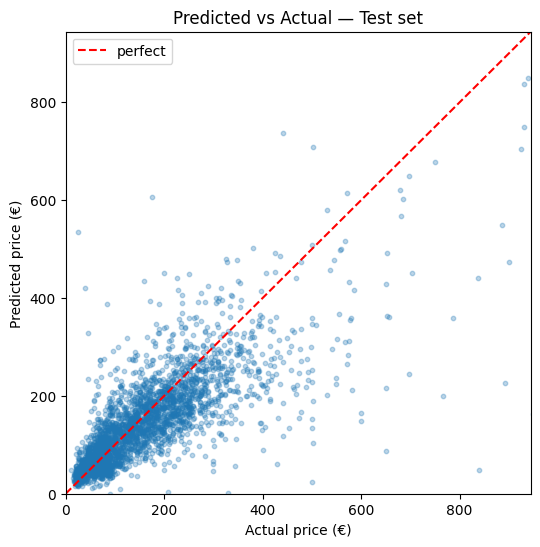

In [453]:
utl.plot_true_versus_predicted(prices_A1, predictions_A1)

## A2

### Load

In [454]:
# Load training sets
X_train_A2 = pd.read_parquet('../data/processed/A2/X_train.parquet', engine='pyarrow')
y_train_A2 = pd.read_parquet('../data/processed/A2/y_train.parquet', engine='pyarrow')
X_test_A2 = pd.read_parquet('../data/processed/A2/X_test.parquet', engine='pyarrow')
y_test_A2 = pd.read_parquet('../data/processed/B1/y_test.parquet', engine='pyarrow')

In [455]:
print(X_train_A2.info(), '\n')
print(X_test_A2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9404 entries, 5483 to 964
Data columns (total 77 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   host_since                                        9404 non-null   float64
 1   host_response_time                                9404 non-null   float64
 2   host_response_rate                                9404 non-null   float64
 3   host_acceptance_rate                              9404 non-null   float64
 4   host_is_superhost                                 9404 non-null   float64
 5   host_listings_count                               9404 non-null   float64
 6   host_has_profile_pic                              9404 non-null   float64
 7   host_identity_verified                            9404 non-null   float64
 8   neighbourhood_cleansed                            9404 non-null   float64
 9   latitude              

Calculate mean and standard deviation of the train set.

In [456]:
# Calculate mean and std
mean_train_A2 = X_train_A2.mean().to_numpy()
std_train_A2 = X_train_A2.std().to_numpy()

Initialise Datasets.

In [457]:
# Init Dataset
dataset_train_A2 = Dataset(X_train_A2, y_train_A2, mean_train_A2, std_train_A2)
dataset_test_A2 = Dataset(X_test_A2, y_test_A2, mean_train_A2, std_train_A2)

Create train and validation sets.

In [458]:
# Split for validation set
size_total = len(dataset_train_A2)
size_val = int(0.1 * size_total)
size_train = size_total - size_val

dataset_train_A2, dataset_val_A2 = torch.utils.data.random_split(
    dataset_train_A2,
    [size_train, size_val]
)

Initialise DataLoaders.

In [459]:
dataloader_train_A2 = torch.utils.data.DataLoader(dataset_train_A2, batch_size=64, shuffle=True)
dataloader_val_A2 = torch.utils.data.DataLoader(dataset_val_A2, batch_size=64, shuffle=False)
dataloader_test_A2 = torch.utils.data.DataLoader(dataset_test_A2, batch_size=64, shuffle=False)

Specify model, optimizer and loss function.

In [460]:
# Hyperparameters
params_A2 = {
    'degree': 2,
    'num_epochs': 30,
    'weight_decay': 0.01,
    'input_dim': X_train_A2.shape[1],
    'output_dim': 1,
    'lr': 0.001
}

In [461]:
model_A2 = PolynomialRegression(input_dim=params_A2['input_dim'], output_dim=params_A2['output_dim'], degree=params_A2['degree']).to(device)
optimizer_A2 = torch.optim.Adam(model_A2.parameters(), lr=params_A2['lr'])
loss_fn = torch.nn.MSELoss()

### Run training

In [462]:
losses_train_A2, losses_val_A2 = run_training(model_A2, optimizer_A2, loss_fn, dataloader_train_A2, dataloader_val_A2, epochs=params_A2['num_epochs'], device=device)
print(losses_train_A2, '\n')
print(losses_val_A2)

100%|██████████| 30/30 [00:27<00:00,  1.09it/s]

[14.123225    3.9054365   1.66099955  0.94002473  0.67614115  0.54401575
  0.46145142  0.39142007  0.34345668  0.30905734  0.28505882  0.26282214
  0.24449712  0.22750948  0.22147213  0.21184521  0.20477996  0.20365425
  0.19874729  0.24360821  0.20289867  0.23848146  0.19238433  0.18573943
  0.18861107  0.17558941  0.17198636  0.18214436  0.18017456  0.1880163 ] 

[3.92610359 1.31625585 0.70788704 0.509871   0.41286065 0.36118759
 0.31616735 0.28927347 0.25949516 0.24113413 0.22702857 0.21159273
 0.20245354 0.19140663 0.18352698 0.17815042 0.1720936  0.16733105
 0.16909835 0.16212814 0.16058125 0.15115503 0.16452137 0.16802413
 0.16094674 0.16320757 0.14505248 0.14678338 0.15976568 0.15999654]


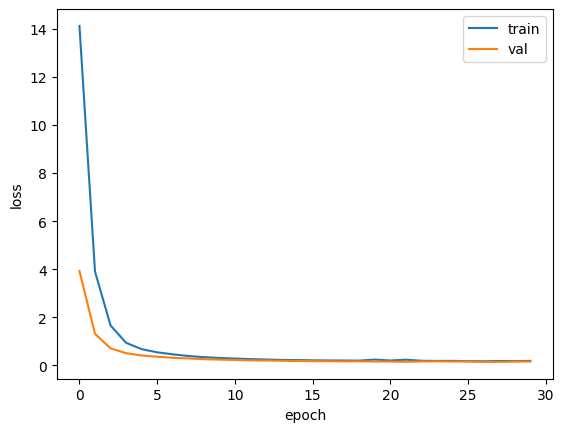

In [463]:
utl.plot_losses(losses_train_A2, losses_val_A2)

### Testing

In [464]:
predictions_A2_log, prices_A2_log, test_loss_A2_log = test_model(model_A2, loss_fn, dataloader_test_A2, device)

test_loss_A2 = np.expm1(test_loss_A2_log)
predictions_A2 = np.expm1(predictions_A2_log).flatten()
prices_A2 = np.expm1(prices_A2_log).flatten()

print('Running loss =', test_loss_A2, '\n')

Running loss = 0.21727138742749524 



In [465]:
utl.show_errors(prices_A2_log, predictions_A2_log)

===== TEST SET =====
RMSE: €117.16
MAE:  €53.17
Median AE:  €27.91
R²:   0.5289

R² (log-scale): 0.6820


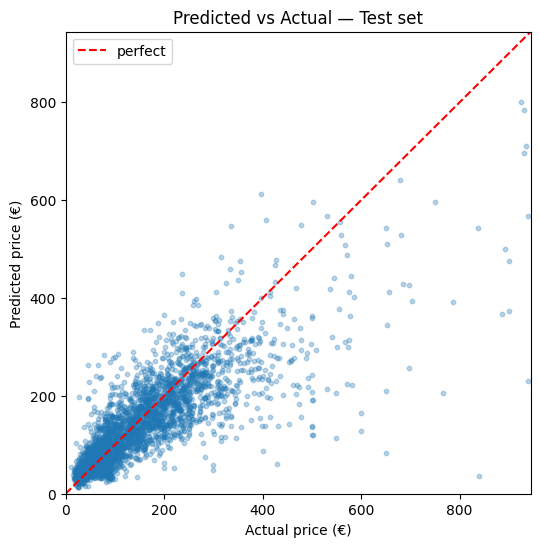

In [466]:
utl.plot_true_versus_predicted(prices_A2, predictions_A2)

## B1

### Load


In [467]:
# Load training sets
X_train_B1 = pd.read_parquet('../data/processed/B1/X_train.parquet', engine='pyarrow')
y_train_B1 = pd.read_parquet('../data/processed/B1/y_train.parquet', engine='pyarrow')
X_test_B1 = pd.read_parquet('../data/processed/B1/X_test.parquet', engine='pyarrow')
y_test_B1 = pd.read_parquet('../data/processed/B1/y_test.parquet', engine='pyarrow')

In [468]:
print(X_train_B1.info(), '\n')
print(X_test_B1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2766 entries, 16596 to 10222
Data columns (total 56 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   host_since                                        2766 non-null   int64  
 1   host_response_time                                2766 non-null   float64
 2   host_response_rate                                2766 non-null   float64
 3   host_acceptance_rate                              2766 non-null   float64
 4   host_is_superhost                                 2766 non-null   float64
 5   host_listings_count                               2766 non-null   float64
 6   host_has_profile_pic                              2766 non-null   int64  
 7   host_identity_verified                            2766 non-null   int64  
 8   neighbourhood_cleansed                            2766 non-null   float64
 9   latitude           

Calculate mean and standard deviation of the train set.

In [469]:
# Calculate mean and std
mean_train_B1 = X_train_B1.mean().to_numpy()
std_train_B1 = X_train_B1.std().to_numpy()

Initialise Datasets.

In [470]:
# Init Dataset
dataset_train_B1 = Dataset(X_train_B1, y_train_B1, mean_train_B1, std_train_B1)
dataset_test_B1 = Dataset(X_test_B1, y_test_B1, mean_train_B1, std_train_B1)

Create train and validation sets.

In [471]:
# Split for validation set
size_total = len(dataset_train_B1)
size_val = int(0.1 * size_total)
size_train = size_total - size_val

dataset_train_B1, dataset_val_B1 = torch.utils.data.random_split(
    dataset_train_B1,
    [size_train, size_val]
)

Initialise DataLoaders.

In [472]:
dataloader_train_B1 = torch.utils.data.DataLoader(dataset_train_B1, batch_size=32, shuffle=True)
dataloader_val_B1 = torch.utils.data.DataLoader(dataset_val_B1, batch_size=32, shuffle=False)
dataloader_test_B1 = torch.utils.data.DataLoader(dataset_test_B1, batch_size=32, shuffle=False)

Specify model, optimizer and loss function.

In [473]:
# Hyperparameters
params_B1 = {
    'degree': 2,
    'num_epochs': 0,
    'weight_decay': 0.01,
    'input_dim': X_train_B1.shape[1],
    'output_dim': 1,
    'lr': 0.001
}

In [474]:
model_B1 = PolynomialRegression(input_dim=params_B1['input_dim'], output_dim=params_B1['output_dim'], degree=params_B1['degree']).to(device)
optimizer_B1 = torch.optim.Adam(model_B1.parameters(), lr=params_B1['lr'])
loss_fn = torch.nn.MSELoss()

### Run training

In [475]:
losses_train_B1, losses_val_B1 = run_training(model_B1, optimizer_B1, loss_fn, dataloader_train_B1, dataloader_val_B1, epochs=params_B1['num_epochs'], device=device)
print(losses_train_B1, '\n')
print(losses_val_B1)

0it [00:00, ?it/s]

[] 

[]


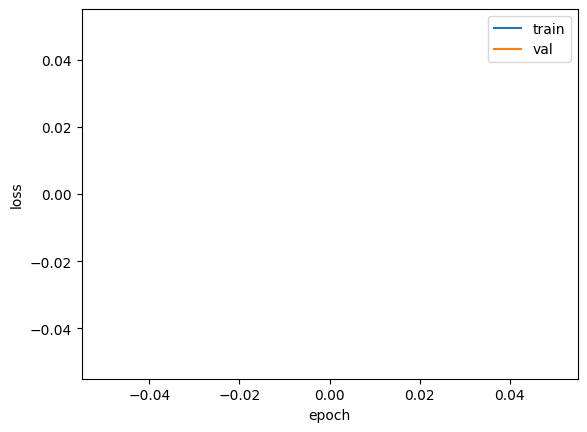

In [476]:
utl.plot_losses(losses_train_B1, losses_val_B1)

### Testing

In [477]:
predictions_B1_log, prices_B1_log, test_loss_B1_log = test_model(model_B1, loss_fn, dataloader_test_B1, device)

test_loss_B1 = np.expm1(test_loss_B1_log)
predictions_B1 = np.expm1(predictions_B1_log).flatten()
prices_B1 = np.expm1(prices_B1_log).flatten()

print('Running loss =', test_loss_B1, '\n')

Running loss = inf 



C:\Users\Victo\AppData\Local\Temp\ipykernel_14888\15144880.py:3: RuntimeWarning: overflow encountered in expm1
  test_loss_B1 = np.expm1(test_loss_B1_log)
C:\Users\Victo\AppData\Local\Temp\ipykernel_14888\15144880.py:4: RuntimeWarning: overflow encountered in expm1
  predictions_B1 = np.expm1(predictions_B1_log).flatten()


In [478]:
# utl.show_errors(prices_B1_log, predictions_B1_log)

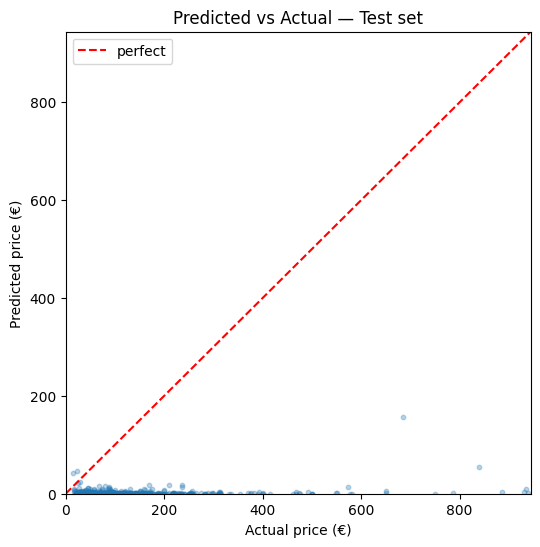

In [479]:
utl.plot_true_versus_predicted(prices_B1, predictions_B1)

## B2

### Load

In [480]:
# Load training sets
X_train_B2 = pd.read_parquet('../data/processed/B2/X_train.parquet', engine='pyarrow')
y_train_B2 = pd.read_parquet('../data/processed/B2/y_train.parquet', engine='pyarrow')
X_test_B2 = pd.read_parquet('../data/processed/B2/X_test.parquet', engine='pyarrow')
y_test_B2 = pd.read_parquet('../data/processed/B2/y_test.parquet', engine='pyarrow')

In [481]:
print(X_train_B2.info(), '\n')
print(X_test_B2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12170 entries, 5483 to 10222
Data columns (total 57 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   host_since                                        12170 non-null  float64
 1   host_response_time                                12170 non-null  float64
 2   host_response_rate                                12170 non-null  float64
 3   host_acceptance_rate                              12170 non-null  float64
 4   host_is_superhost                                 12170 non-null  float64
 5   host_listings_count                               12170 non-null  float64
 6   host_has_profile_pic                              12170 non-null  float64
 7   host_identity_verified                            12170 non-null  float64
 8   neighbourhood_cleansed                            12170 non-null  float64
 9   latitude           

Calculate mean and standard deviation of the train set.

In [482]:
# Calculate mean and std
mean_train_B2 = X_train_B2.mean().to_numpy()
std_train_B2 = X_train_B2.std().to_numpy()

Initialise Datasets.

In [483]:
# Init Dataset
dataset_train_B2 = Dataset(X_train_B2, y_train_B2, mean_train_B2, std_train_B2)
dataset_test_B2 = Dataset(X_test_B2, y_test_B2, mean_train_B2, std_train_B2)

Create train and validation sets.

In [484]:
# Split for validation set
size_total = len(dataset_train_B2)
size_val = int(0.1 * size_total)
size_train = size_total - size_val

dataset_train_B2, dataset_val_B2 = torch.utils.data.random_split(
    dataset_train_B2,
    [size_train, size_val]
)

Initialise DataLoaders.

In [485]:
dataloader_train_B2 = torch.utils.data.DataLoader(dataset_train_B2, batch_size=64, shuffle=True)
dataloader_val_B2 = torch.utils.data.DataLoader(dataset_val_B2, batch_size=64, shuffle=False)
dataloader_test_B2 = torch.utils.data.DataLoader(dataset_test_B2, batch_size=64, shuffle=False)

Specify model, optimizer and loss function.

In [486]:
# Hyperparameters
params_B2 = {
    'degree': 2,
    'num_epochs': 30,
    'weight_decay': 0.01,
    'input_dim': X_train_B2.shape[1],
    'output_dim': 1,
    'lr': 0.001
}

In [487]:
model_B2 = PolynomialRegression(input_dim=params_B2['input_dim'], output_dim=params_B2['output_dim'], degree=params_B2['degree']).to(device)
optimizer_B2 = torch.optim.Adam(model_B2.parameters(), lr=params_B2['lr'])
loss_fn = torch.nn.MSELoss()

### Run training

In [488]:
losses_train_B2, losses_val_B2 = run_training(model_B2, optimizer_B2, loss_fn, dataloader_train_B2, dataloader_val_B2, epochs=params_B2['num_epochs'], device=device)
print(losses_train_B2, '\n')
print(losses_val_B2)

100%|██████████| 30/30 [00:35<00:00,  1.18s/it]

[14.38036295  2.80208806  1.39912274  0.87491702  0.61609006  0.49242724
  0.44201046  0.38398036  0.33704722  0.30786752  0.28043631  0.24358354
  0.23604513  0.21623906  0.20987696  0.19512964  0.19015099  0.19105642
  0.19108781  0.19382569  0.19349332  0.20449875  0.1966285   0.22450107
  0.35980388  0.43051408  0.37718935  0.31104424  0.21306643  0.21047316] 

[2.39598328 0.71720507 0.48076077 0.40217017 0.35972848 0.33555868
 0.31889816 0.30312436 0.28541409 0.28632281 0.27798078 0.24121418
 0.24803348 0.21064483 0.21128355 0.32229223 0.24064317 0.22916803
 0.23178032 0.27210296 0.23883064 0.23293011 0.20609347 0.22425896
 0.21958885 0.2146114  0.20480021 0.21465684 0.29970688 0.25712049]


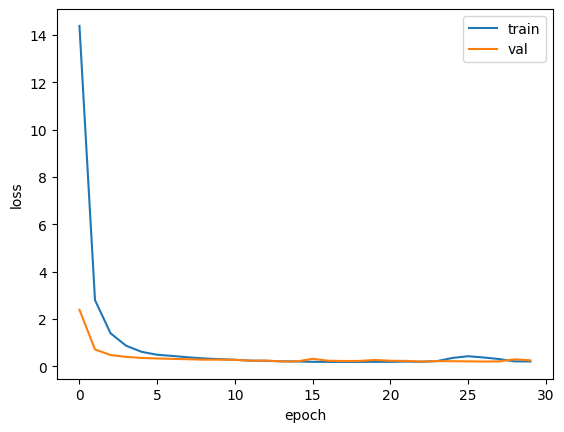

In [489]:
utl.plot_losses(losses_train_B2, losses_val_B2)

### Testing

In [490]:
predictions_B2_log, prices_B2_log, test_loss_B2_log = test_model(model_B2, loss_fn, dataloader_test_B2, device)

test_loss_B2 = np.expm1(test_loss_B2_log).flatten()
predictions_B2 = np.expm1(predictions_B2_log).flatten()
prices_B2 = np.expm1(prices_B2_log).flatten()

print('Running loss =', test_loss_B2, '\n')

Running loss = [0.20247935] 



In [491]:
utl.show_errors(prices_B2_log, predictions_B2_log)

===== TEST SET =====
RMSE: €112.37
MAE:  €51.87
Median AE:  €27.47
R²:   0.5667

R² (log-scale): 0.7017


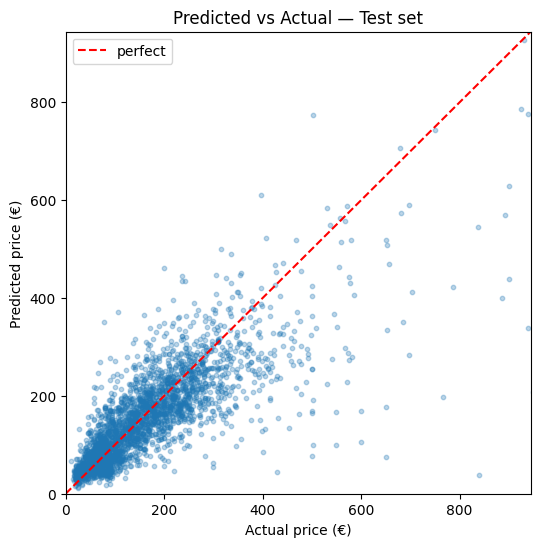

In [492]:
utl.plot_true_versus_predicted(prices_B2, predictions_B2)